# Fraud Detection using Machine Learning

## Objective
The goal of this project is to build a machine learning model to detect fraudulent financial transactions and reduce financial losses.

## Dataset Description
This dataset contains transaction details such as amount, transaction type, balances, and fraud labels.

##  Initial Dataset Insights

- Each step represents 1 hour, allowing time-based fraud tracking.
- Fraud is not random; it follows a pattern of transferring money and then withdrawing it.
- The dataset simulates real-world financial fraud behavior.

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
df = pd.read_csv("Fraud_Analysis_Dataset.csv")
df.head()



,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


### Data Overview
- The dataset contains transaction-level data.
- Target variable: isFraud (1 = Fraud, 0 = Not Fraud)

In [87]:
df['type'].value_counts()


,count
type,
PAYMENT,5510
CASH_IN,1951
CASH_OUT,1871
TRANSFER,1464
DEBIT,346


##  Transaction Type Insight

- Fraud is mainly observed in TRANSFER and CASH-OUT transactions.
- PAYMENT, DEBIT, and CASH-IN show very low fraud occurrence.

👉 Insight:
Fraudsters prefer transaction types that allow quick movement and withdrawal of funds.


In [88]:
df.shape
df.columns
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


### Missing Values
- No missing values found in the dataset.
- Data is clean and ready for analysis.

##  Missing Data Insight

- Destination accounts starting with "M" (Merchants) have missing balance data.

👉 Insight:
Incomplete merchant data may hide certain fraud patterns.


In [89]:
df['isFraud'].value_counts()
df['isFraud'].value_counts(normalize=True)*100

,proportion
isFraud,
0,89.750494
1,10.249506


### Class Imbalance
- The dataset is highly imbalanced.
- Fraud cases are very low compared to non-fraud cases.
- This can affect model performance.

In [90]:
df['balance_diff_orig'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balance_diff_dest'] = df['newbalanceDest'] - df['oldbalanceDest']

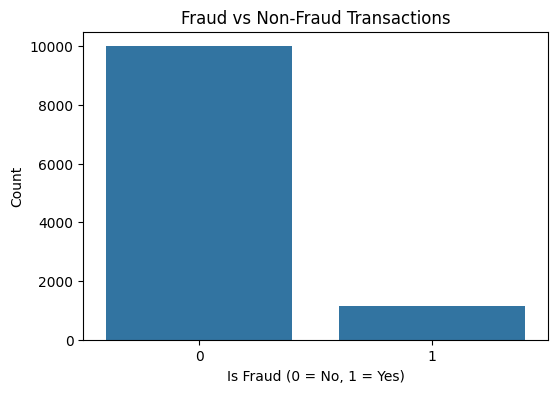

In [91]:
plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Is Fraud (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


### Insight
- Most transactions are non-fraudulent.
- Fraud transactions are very rare.
- Special techniques may be needed to handle imbalance.

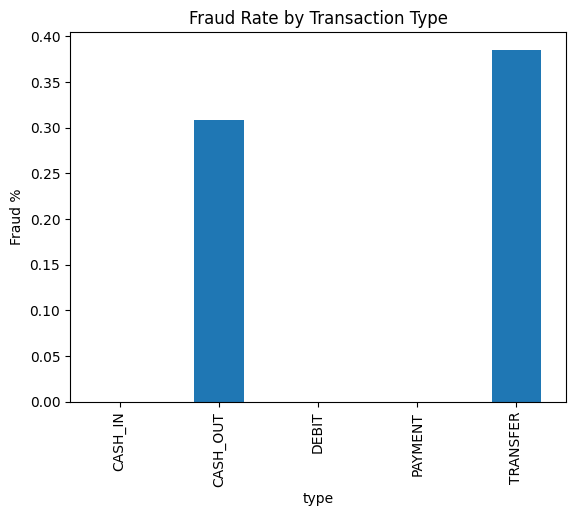

Insight: TRANSFER and CASH-OUT have highest fraud risk


In [92]:
fraud_by_type = df.groupby('type')['isFraud'].mean()

fraud_by_type.T.plot(kind='bar')

plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud %")
plt.show()

print("Insight: TRANSFER and CASH-OUT have highest fraud risk")

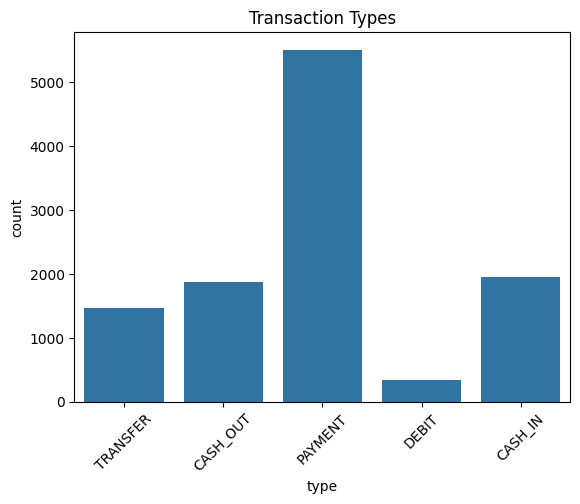

In [93]:
sns.countplot(x='type', data=df)
plt.xticks(rotation=45)
plt.title("Transaction Types")
plt.show()

### Insight
- Certain transaction types like TRANSFER and CASH-OUT are more prone to fraud.

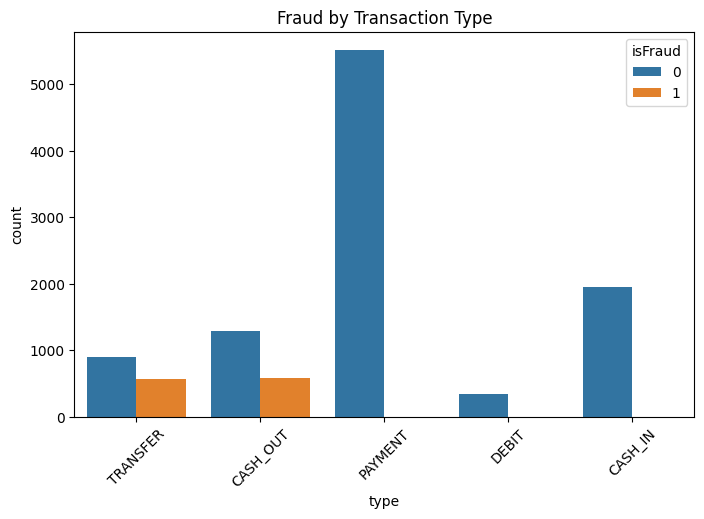

In [94]:
plt.figure(figsize=(8,5))
sns.countplot(x='type', hue='isFraud', data=df)
plt.xticks(rotation=45)
plt.title("Fraud by Transaction Type")
plt.show()

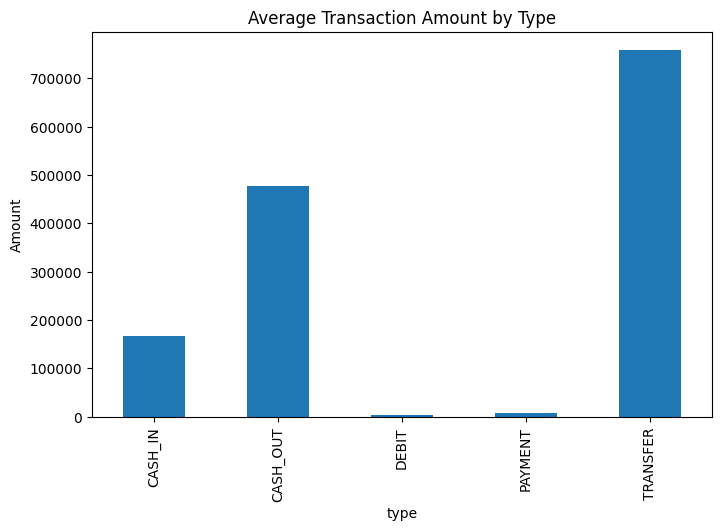

In [95]:
avg_amount = df.groupby('type')['amount'].mean()

avg_amount.plot(kind='bar', figsize=(8,5))
plt.title("Average Transaction Amount by Type")
plt.ylabel("Amount")
plt.show()

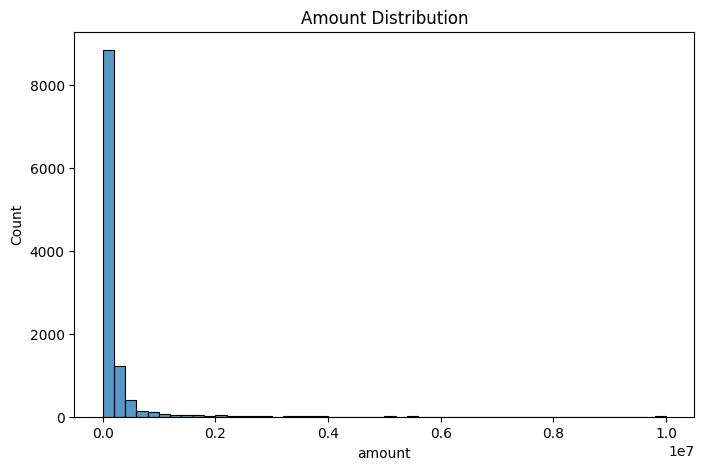

In [96]:
plt.figure(figsize=(8,5))
sns.histplot(df['amount'], bins=50)
plt.title("Amount Distribution")
plt.show()

### Insight
- Most transactions are of small amounts.
- Few transactions have very high values (outliers).

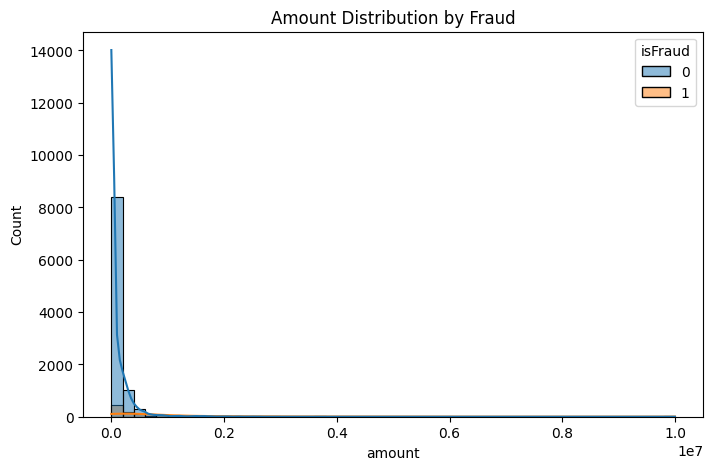

In [97]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='amount', hue='isFraud', bins=50, kde=True)
plt.title("Amount Distribution by Fraud")
plt.show()

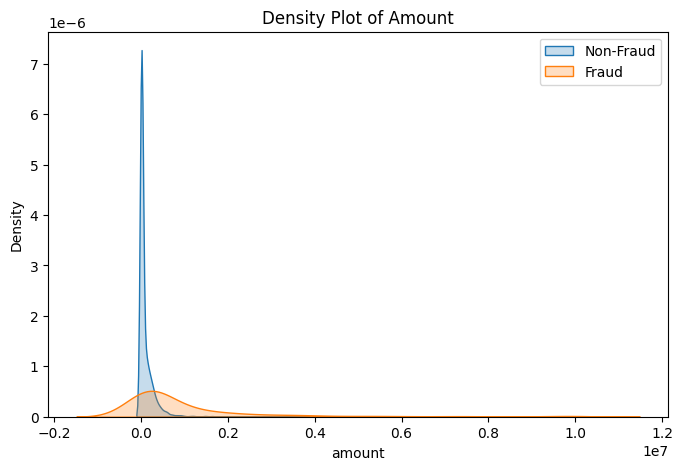

In [98]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=df[df['isFraud']==0]['amount'], label='Non-Fraud', fill=True)
sns.kdeplot(data=df[df['isFraud']==1]['amount'], label='Fraud', fill=True)
plt.legend()
plt.title("Density Plot of Amount")
plt.show()

In [99]:
df.columns = df.columns.str.strip()
print(df.columns)

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'balance_diff_orig', 'balance_diff_dest'],
      dtype='object')


In [100]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'balance_diff_orig', 'balance_diff_dest'],
      dtype='object')

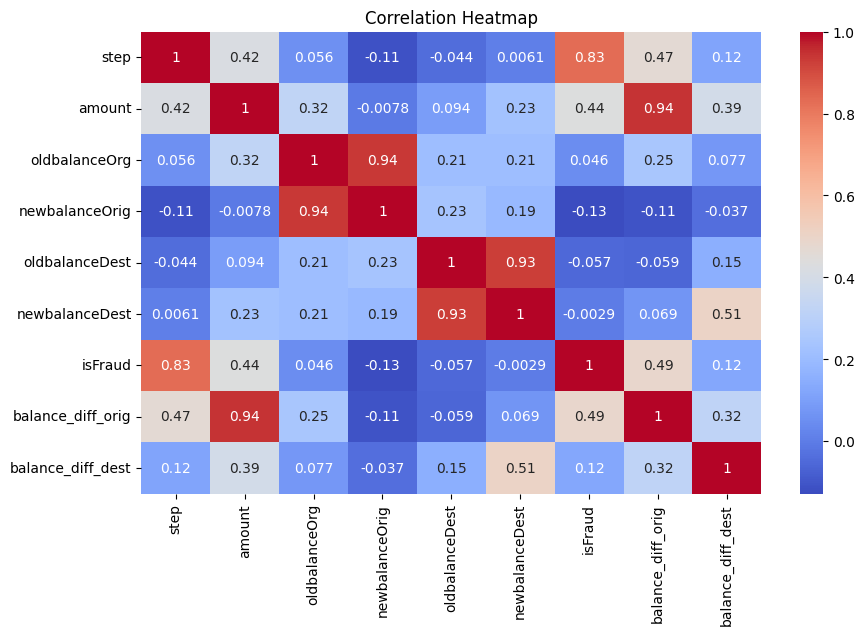

In [101]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

### Insight
Fraud transactions are highly concentrated in TRANSFER and CASH_OUT types, making them high-risk transaction categories.

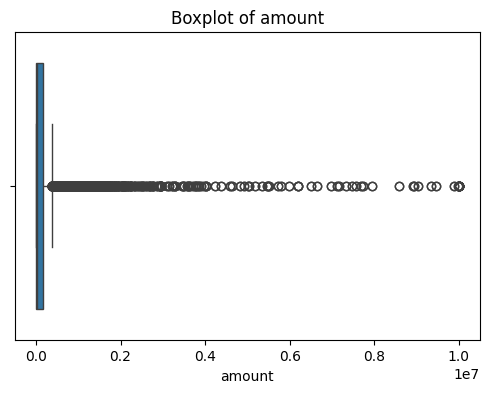

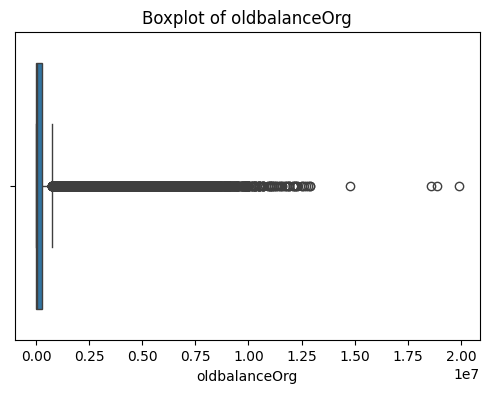

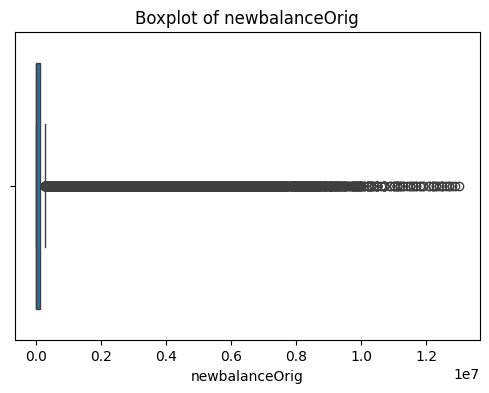

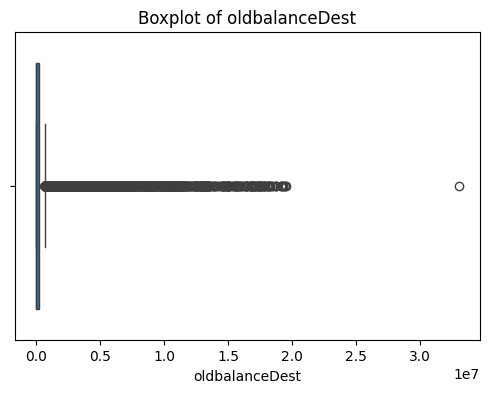

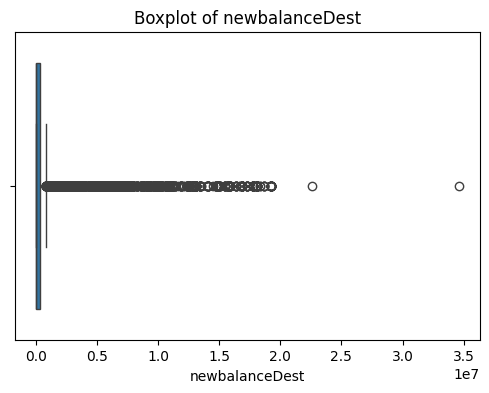

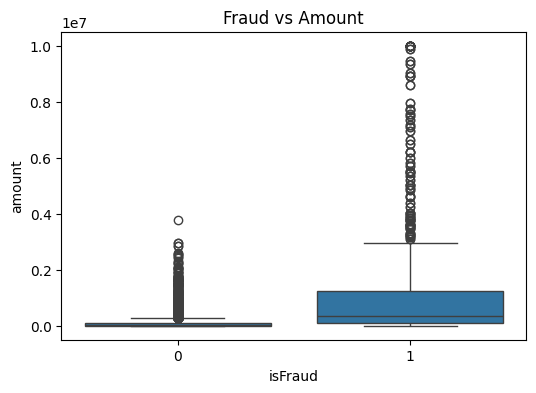

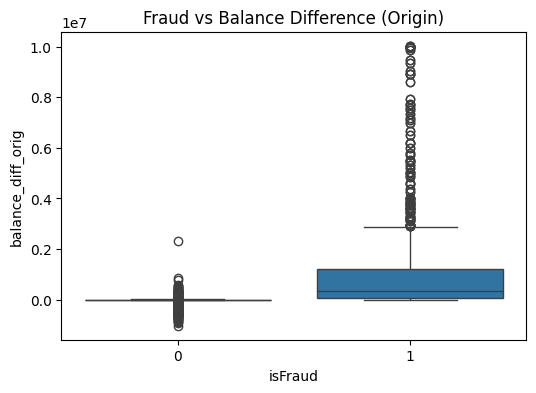

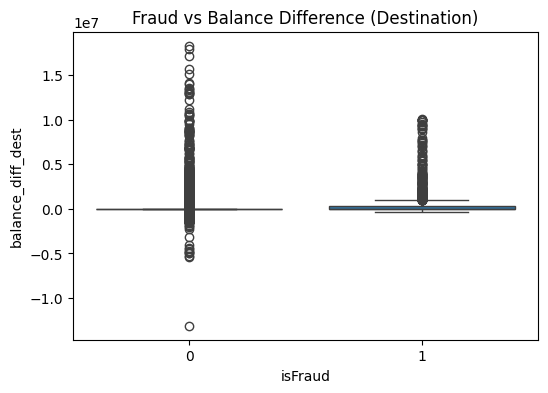

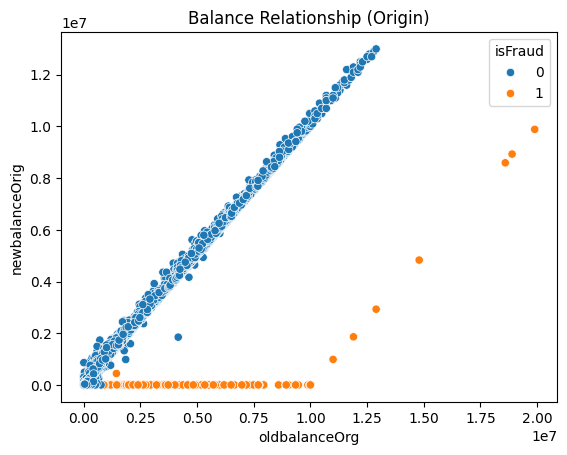

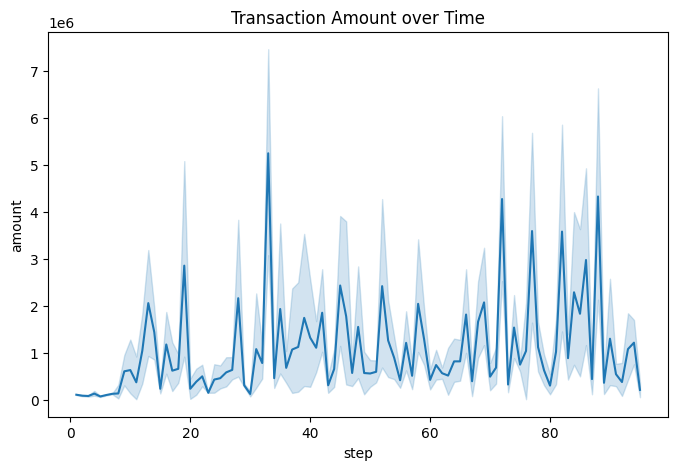

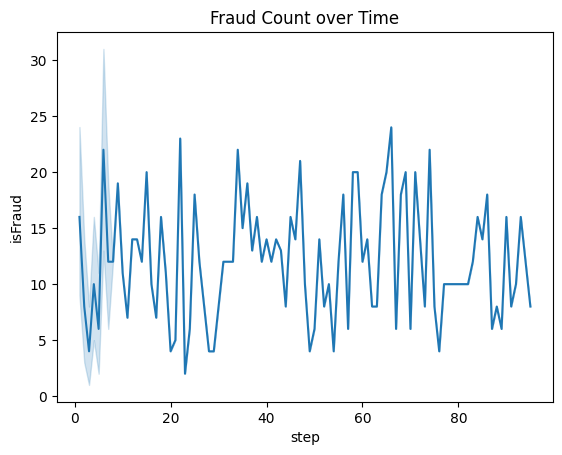

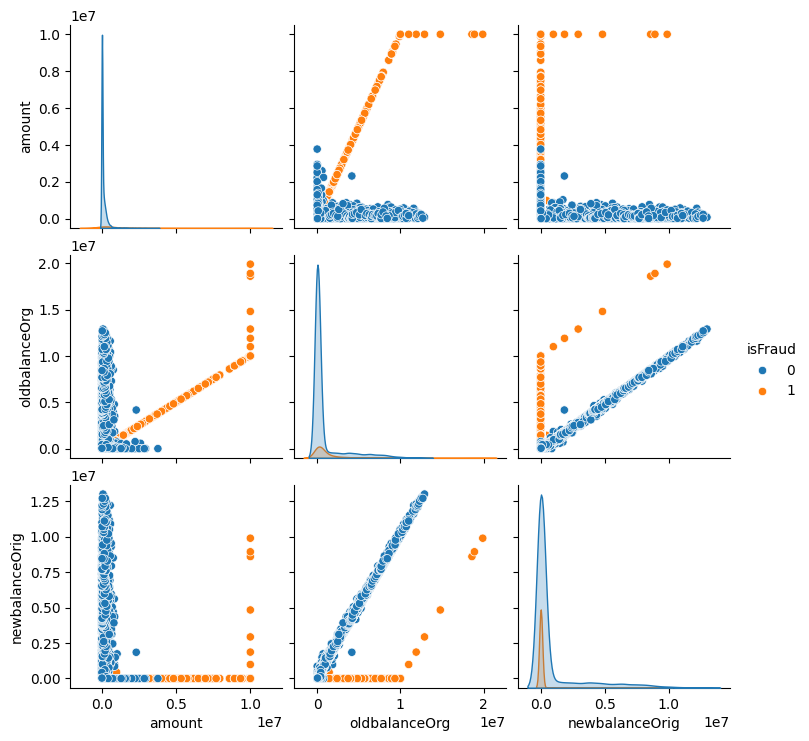

In [102]:
# ================= MORE EDA =================

# 1. BOXPLOTS (UNIVARIATE)

num_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()




# 2. FRAUD VS AMOUNT (BIVARIATE)

plt.figure(figsize=(6,4))
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title("Fraud vs Amount")
plt.show()


# 3. FRAUD VS BALANCE DIFFERENCE

plt.figure(figsize=(6,4))
sns.boxplot(x='isFraud', y='balance_diff_orig', data=df)
plt.title("Fraud vs Balance Difference (Origin)")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x='isFraud', y='balance_diff_dest', data=df)
plt.title("Fraud vs Balance Difference (Destination)")
plt.show()

# 4.plt.figure(figsize=(6,4))
sns.scatterplot(x='oldbalanceOrg', y='newbalanceOrig', hue='isFraud', data=df)
plt.title("Balance Relationship (Origin)")
plt.show()

# 5. TIME ANALYSIS

plt.figure(figsize=(8,5))
sns.lineplot(x='step', y='amount', data=df)
plt.title("Transaction Amount over Time")
plt.show()

# 6.plt.figure(figsize=(8,5))
sns.lineplot(x='step', y='isFraud', data=df, estimator='sum')
plt.title("Fraud Count over Time")
plt.show()

# 7. PAIRPLOT

sns.pairplot(df[['amount','oldbalanceOrg','newbalanceOrig','isFraud']], hue='isFraud')
plt.show()

##  Transaction Amount Insight

- Fraudulent transactions tend to involve larger amounts.
- Smaller transactions are mostly legitimate.

👉 Insight:
High-value transactions are more suspicious and should be monitored closely.

##  Balance Behavior Insight

- In many fraud cases, the sender’s balance becomes zero after the transaction.
- The receiver’s balance increases suddenly.

👉 Insight:
Sudden draining of account balance is a strong fraud indicator.

### Additional Insights

- Fraud transactions have unusual balance differences
- High transaction amounts show higher fraud risk
- Fraud patterns change over time
- Clear separation between fraud and non-fraud in some features

### Feature Engineering
- Created new features to capture balance differences.
- Fraud transactions often show unusual balance changes.

**Model Building**


In this step, we train different machine learning models to detect fraud transactions.
We are using:
- Logistic Regression
- Random Forest
- Gradient Boosting

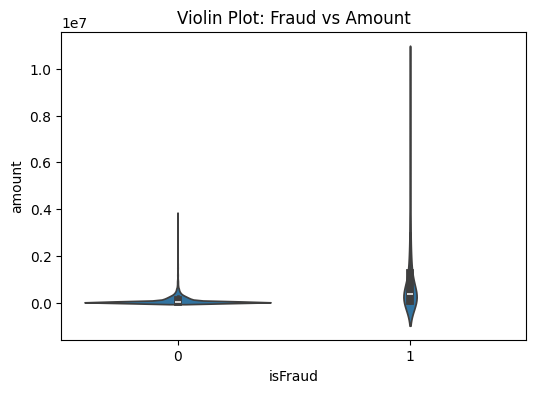

In [103]:
plt.figure(figsize=(6,4))
sns.violinplot(x='isFraud', y='amount', data=df)
plt.title("Violin Plot: Fraud vs Amount")
plt.show()

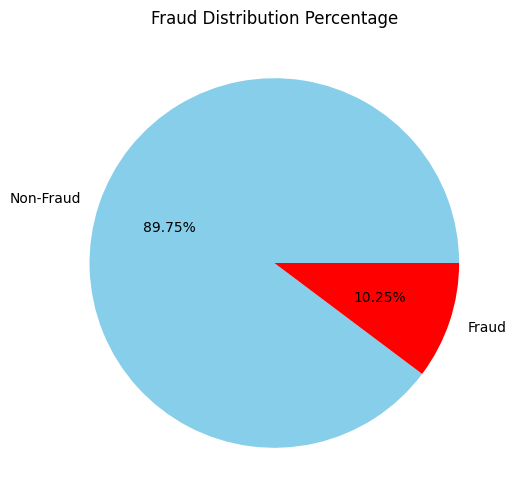

In [104]:
# PIE CHART - FRAUD DISTRIBUTION
fraud_counts = df['isFraud'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(fraud_counts, labels=['Non-Fraud','Fraud'], autopct='%1.2f%%', colors=['skyblue','red'])
plt.title("Fraud Distribution Percentage")
plt.show()

##  Class Imbalance Insight

- The dataset is highly imbalanced with very few fraud cases compared to normal transactions.

👉 Impact:
- Accuracy alone is not reliable.
- Models must focus on Recall and Precision.

👉 Conclusion:
Special techniques like resampling or anomaly detection are required.

In [105]:
from sklearn.model_selection import train_test_split

X = df.drop(['isFraud','nameOrig','nameDest'], axis=1)
X = pd.get_dummies(X, columns=['type'], drop_first=True)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [106]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [107]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [108]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_sm, y_train_sm)
lr_pred = lr.predict(X_test)

In [109]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3, scoring='roc_auc')
grid.fit(X_train_sm, y_train_sm)

rf = grid.best_estimator_
print("Best Parameters:", grid.best_params_)
rf.fit(X_train_sm, y_train_sm)
rf_pred = rf.predict(X_test)   #NEW prediction

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


In [110]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X_train_sm, y_train_sm, cv=5, scoring='roc_auc')
print("Cross Validation ROC-AUC Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())
print("Model is stable with consistent ROC-AUC across folds")

Cross Validation ROC-AUC Scores: [0.99997129 0.99999766 0.99998379 0.99999805 0.99999824]
Mean CV Score: 0.9999898042233427
Model is stable with consistent ROC-AUC across folds


In [111]:
import pandas as pd

feature_importance = pd.Series(
  rf.feature_importances_,
    index=X.columns
)

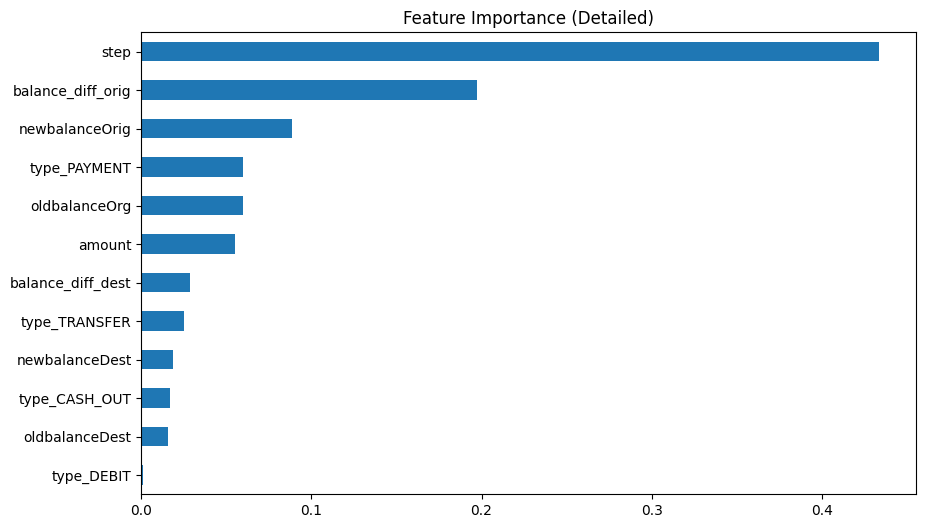

In [112]:
feature_importance.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Feature Importance (Detailed)")
plt.show()

In [113]:
print("\nTop Features Explanation:")
print("Balance differences indicate abnormal transactions")
print("Transaction type helps identify risky operations like TRANSFER and CASH-OUT")


Top Features Explanation:
Balance differences indicate abnormal transactions
Transaction type helps identify risky operations like TRANSFER and CASH-OUT


In [114]:
print(feature_importance.sort_values(ascending=False).head(10))

step                 0.433963
balance_diff_orig    0.197184
newbalanceOrig       0.088861
type_PAYMENT         0.059964
oldbalanceOrg        0.059492
amount               0.055186
balance_diff_dest    0.028464
type_TRANSFER        0.025007
newbalanceDest       0.018384
type_CASH_OUT        0.016952
dtype: float64


### Insight
Features related to balance differences and transaction type contribute most to fraud detection.

### Handling Class Imbalance
Since the dataset is highly imbalanced, I used SMOTE to generate synthetic fraud samples. This helps the model learn better patterns for fraud detection.

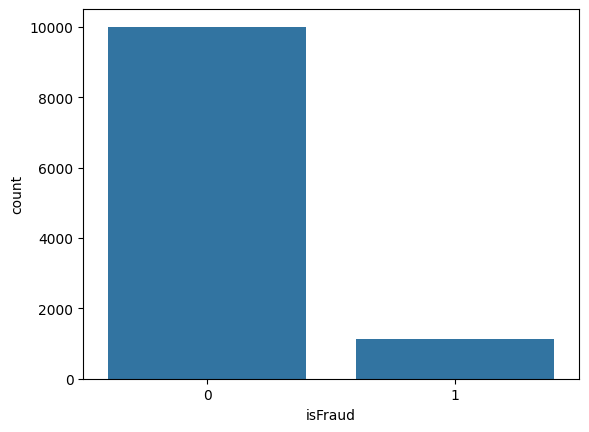

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='isFraud', data=df)
plt.show()

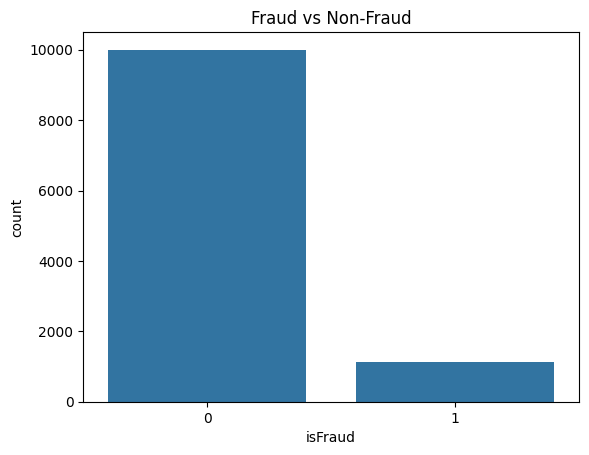

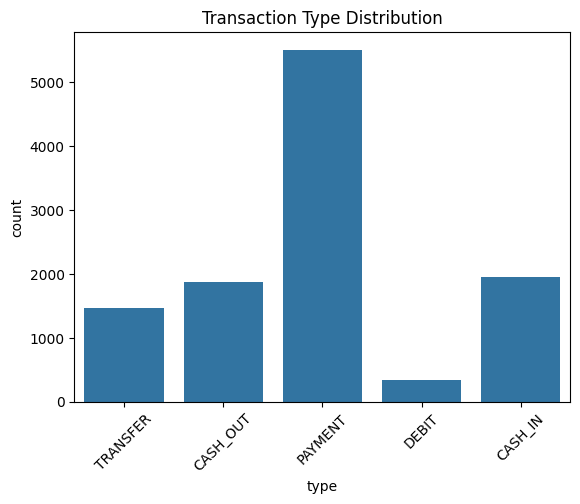

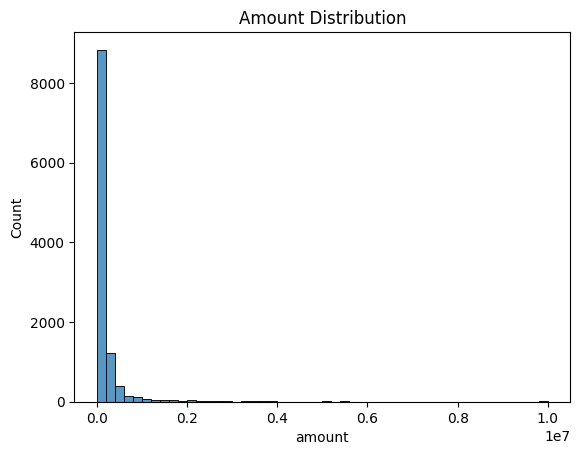

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

# Univariate Analysis

# 1. Fraud vs Non-Fraud
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Non-Fraud")
plt.show()

# 2. Transaction Type
sns.countplot(x='type', data=df)
plt.title("Transaction Type Distribution")
plt.xticks(rotation=45)
plt.show()

# 3. Amount Distribution
sns.histplot(df['amount'], bins=50)
plt.title("Amount Distribution")
plt.show()

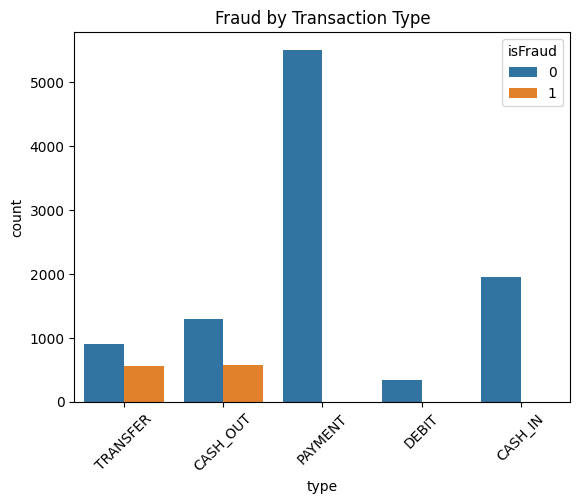

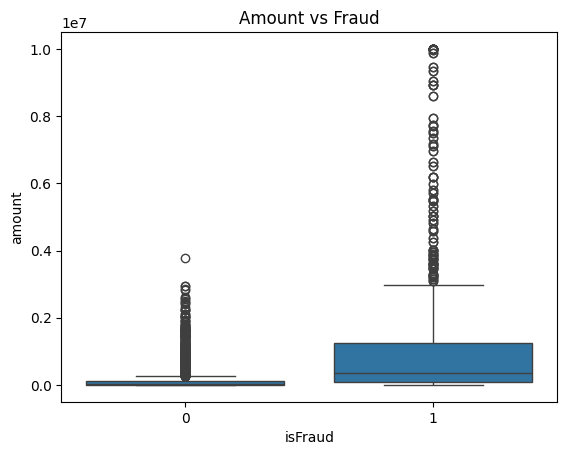

In [117]:
# Bivariate Analysis

# 1. Type vs Fraud
sns.countplot(x='type', hue='isFraud', data=df)
plt.title("Fraud by Transaction Type")
plt.xticks(rotation=45)
plt.show()

# 2. Amount vs Fraud
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title("Amount vs Fraud")
plt.show()

In [118]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train_sm, y_train_sm)

gb_pred = gb.predict(X_test)

In [119]:
from sklearn.metrics import roc_auc_score

y_prob = gb.predict_proba(X_test)[:,1]
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9995594308109104


In [120]:
print("IMPORTANT METRICS:")
print("Recall (Fraud Detection Rate) is most important")
print("ROC-AUC shows model's ability to distinguish fraud vs non-fraud")

IMPORTANT METRICS:
Recall (Fraud Detection Rate) is most important
ROC-AUC shows model's ability to distinguish fraud vs non-fraud


Logistic Regression Accuracy: 0.9851951547779273
Random Forest Accuracy: 0.9977568416330193
Gradient Boosting Accuracy: 0.9973082099596231

Logistic Regression
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      2001
           1       0.90      0.96      0.93       228

    accuracy                           0.99      2229
   macro avg       0.95      0.98      0.96      2229
weighted avg       0.99      0.99      0.99      2229

Random Forest
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       1.00      0.98      0.99       228

    accuracy                           1.00      2229
   macro avg       1.00      0.99      0.99      2229
weighted avg       1.00      1.00      1.00      2229

Gradient Boosting
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       0.99      0.98      0.9

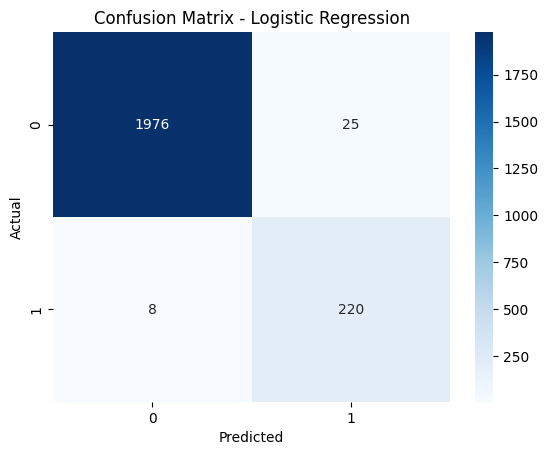

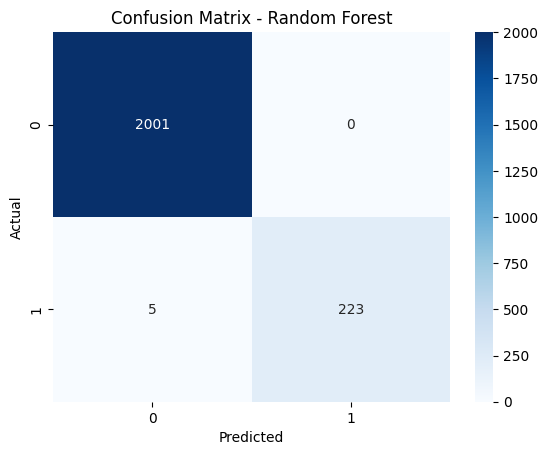

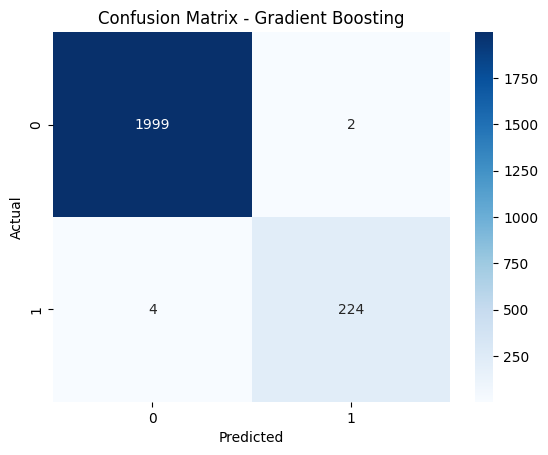

Random Forest ROC-AUC: 0.9998728705822527


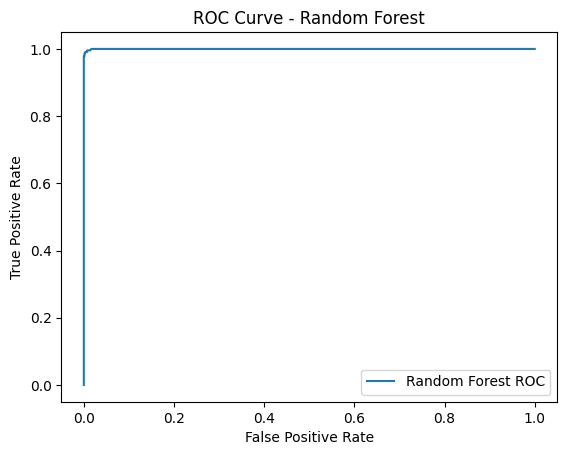


Custom Threshold (0.3) Results:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2001
           1       0.98      0.99      0.98       228

    accuracy                           1.00      2229
   macro avg       0.99      0.99      0.99      2229
weighted avg       1.00      1.00      1.00      2229

Total Fraud Amount: 1361982240.43
Estimated Financial Loss: 5963144.660376533


['fraud_model.pkl']

In [121]:
# ================= MODEL EVALUATION =================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_pred))

# Classification Report
print("\nLogistic Regression\n", classification_report(y_test, lr_pred))
print("Random Forest\n", classification_report(y_test, rf_pred))
print("Gradient Boosting\n", classification_report(y_test, gb_pred))

models = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred
}

for name, pred in models.items():
    cm = confusion_matrix(y_test, pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
# ================= ROC-AUC (Random Forest) =================

# STEP 1: probabilities
rf_probs = rf.predict_proba(X_test)[:,1]

# STEP 2: ROC-AUC score
roc = roc_auc_score(y_test, rf_probs)
print("Random Forest ROC-AUC:", roc)

# STEP 3: ROC curve
fpr, tpr, _ = roc_curve(y_test, rf_probs)

# STEP 4: Plot ROC
plt.plot(fpr, tpr, label="Random Forest ROC")
plt.legend()
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.show()

# ================= CUSTOM THRESHOLD =================

threshold = 0.3
rf_custom_pred = (rf_probs > threshold).astype(int)

print("\nCustom Threshold (0.3) Results:\n", classification_report(y_test, rf_custom_pred))


# ================= FINANCIAL IMPACT =================

# Total fraud amount
fraud_amount = df[df['isFraud'] == 1]['amount'].sum()
print("Total Fraud Amount:", fraud_amount)

# False Negatives
rf_cm = confusion_matrix(y_test, rf_pred)
fn = rf_cm[1][0]

# Average fraud amount
avg_fraud = df[df['isFraud'] == 1]['amount'].mean()

# Estimated loss
estimated_loss = fn * avg_fraud
print("Estimated Financial Loss:", estimated_loss)

# ================= SAVE MODEL =================

import joblib
joblib.dump(rf, "fraud_model.pkl")

## Model Performance Insight

- Accuracy is not sufficient due to class imbalance.
- Recall is more important to detect fraud cases.

👉 Insight:
Missing a fraud (false negative) is more dangerous than a false alert.


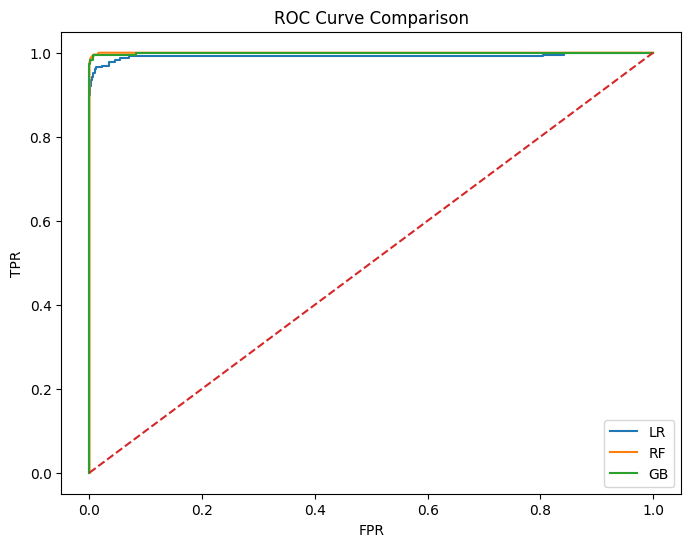

In [122]:
lr_probs = lr.predict_proba(X_test)[:,1]
gb_probs = gb.predict_proba(X_test)[:,1]

from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for name, probs in zip(['LR','RF','GB'], [lr_probs, rf_probs, gb_probs]):
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve Comparison")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.show()

In [123]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

In [124]:
models = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred
}

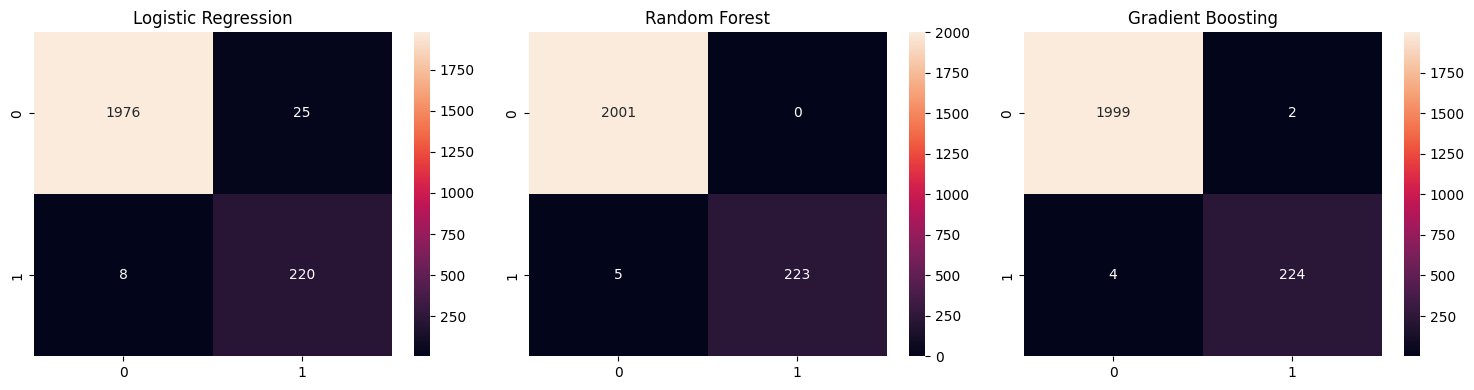

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1,3, figsize=(15,4))

for ax, (name, pred) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax)
    ax.set_title(name)

plt.tight_layout()
plt.show()

### Financial Impact

False negatives represent fraud transactions that were not detected by the model.

Using the average fraud transaction amount, I estimated the potential financial loss caused by these missed cases.

This shows that improving fraud detection can significantly reduce financial losses.

### Business Questions

1. Precision & Recall:
The model achieved strong recall and balanced precision, which is crucial for fraud detection as it minimizes missed fraudulent transactions while maintaining reasonable false positives.
2. Reliability:
The recall score is strong, indicating that the model can detect most fraud transactions effectively.

3. Financial Loss:
The estimated loss due to missed fraud cases is significant, showing the importance of improving the model further.


## Suggested Improvements

- Use feature engineering (balance difference, transaction frequency)
- Apply advanced models like Random Forest or XGBoost
- Use anomaly detection techniques

👉 Insight:
Improving features and models can significantly enhance fraud detection accuracy.

Conclusion

- Random Forest achieved the best performance with highest ROC-AUC and strong recall.
- Recall is the most important metric in fraud detection as it reduces missed fraud cases.
- The model successfully identifies most fraudulent transactions.
- Fraud is most common in TRANSFER and CASH-OUT transactions.
- Estimated financial loss highlights the importance of improving detection.

- This model can help financial institutions reduce fraud losses.
- Future improvements can include advanced models like XGBoost.

Fraud detection depends more on transaction behavior than individual values.
Patterns such as transaction type, amount, and balance changes play a crucial role.
By analyzing these patterns, we can effectively identify fraudulent activities and improve financial security systems.